# 🧠 Brain Tumor MRI Classification (CNN) - FINAL COLAB NOTEBOOK (ZIP Upload)

Dataset Format Supported:
- brain_tumor_mri (1).zip
  └── new_dataset/
      ├── bt_images/
      ├── labels.pickle
      └── training_data.pickle

This notebook is 100% ready for submission and works directly with ZIP upload in Google Colab.

## 📌 Step 1: Upload ZIP Dataset

In [7]:
from google.colab import files
uploaded = files.upload()  # Upload brain_tumor_mri (1).zip

Saving brain_tumor_mri (1).zip to brain_tumor_mri (1).zip


## 📦 Step 2: Unzip the Dataset

In [9]:
!unzip -o "brain_tumor_mri (1).zip"

Archive:  brain_tumor_mri (1).zip
  inflating: new_dataset/bt_images/1.jpg  
  inflating: new_dataset/bt_images/10.jpg  
  inflating: new_dataset/bt_images/100.jpg  
  inflating: new_dataset/bt_images/1000.jpg  
  inflating: new_dataset/bt_images/1001.jpg  
  inflating: new_dataset/bt_images/1002.jpg  
  inflating: new_dataset/bt_images/1003.jpg  
  inflating: new_dataset/bt_images/1004.jpg  
  inflating: new_dataset/bt_images/1005.jpg  
  inflating: new_dataset/bt_images/1006.jpg  
  inflating: new_dataset/bt_images/1007.jpg  
  inflating: new_dataset/bt_images/1008.jpg  
  inflating: new_dataset/bt_images/1009.jpg  
  inflating: new_dataset/bt_images/101.jpg  
  inflating: new_dataset/bt_images/1010.jpg  
  inflating: new_dataset/bt_images/1011.jpg  
  inflating: new_dataset/bt_images/1012.jpg  
  inflating: new_dataset/bt_images/1013.jpg  
  inflating: new_dataset/bt_images/1014.jpg  
  inflating: new_dataset/bt_images/1015.jpg  
  inflating: new_dataset/bt_images/1016.jpg  
  infla

## 📚 Step 3: Import Libraries

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## 📥 Step 4: Load Pickle Data

In [13]:
# STEP 4: Load dataset from pickle files
dataset_path = "/content/new_dataset"

with open(os.path.join(dataset_path, "training_data.pickle"), "rb") as f:
    training_data = pickle.load(f)

print("Type of dataset:", type(training_data))
print("Total samples:", len(training_data))
print("Type of first element:", type(training_data[0]))
print("Length of first element:", len(training_data[0]))

Type of dataset: <class 'list'>
Total samples: 3064
Type of first element: <class 'list'>
Length of first element: 2


In [31]:
import os
print(os.listdir('/content/new_dataset'))

['labels.pickle', 'bt_images', 'training_data.pickle']


## STEP 5: Extract X (images) and y (labels)

In [10]:
import pickle
import numpy as np
import os
import cv2

dataset_folder = "/content/new_dataset"
image_folder = dataset_folder + "/bt_images"

# Load labels
with open(dataset_folder + "/labels.pickle", "rb") as f:
    labels = pickle.load(f)

X = []
for img_name in sorted(os.listdir(image_folder), key=lambda x: int(x.split('.')[0])):
    img_path = os.path.join(image_folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (128, 128))  # 🔴 CHANGED (RAM SAFE)
    X.append(img)

X = np.array(X) / 255.0
y = np.array(labels)

print("Images shape:", X.shape)

Images shape: (3064, 128, 128, 3)


In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)  # 🔴 UPDATED
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=8,          # reduced (saves RAM & time)
    batch_size=8,      # 🔴 VERY IMPORTANT (was 32 → caused crash)
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 193s 595ms/step - accuracy: 0.4519 - loss: 1.0988 - val_accuracy: 0.5775 - val_loss: 0.9044
Epoch 2/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 198s 584ms/step - accuracy: 0.5935 - loss: 0.9032 - val_accuracy: 0.6493 - val_loss: 0.8816
Epoch 3/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 176s 573ms/step - accuracy: 0.6493 - loss: 0.8049 - val_accuracy: 0.6183 - val_loss: 0.7771
Epoch 4/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 182s 593ms/step - accuracy: 0.6729 - loss: 0.7450 - val_accuracy: 0.6525 - val_loss: 0.7462
Epoch 5/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 196s 575ms/step - accuracy: 0.6717 - loss: 0.7457 - val_accuracy: 0.6917 - val_loss: 0.6937
Epoch 6/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 183s 595ms/step - accuracy: 0.6817 - loss: 0.7156 - val_accuracy: 0.7292 - val_loss: 0.6934
Epoch 7/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 192s 627ms/step - accuracy: 0.6965 - loss: 0.6885 - val_accuracy: 0.7064 - val_loss: 0.7177
Epoch 8/8
307/307 ━━━━━━━━━━━━━━━━━━━━ 184s 568ms/step - accuracy: 0.7262 - loss: 0

In [13]:
# Unfreeze last 30 layers of ResNet50
for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate (VERY IMPORTANT)
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Top 30 layers unfrozen for fine-tuning")

Top 30 layers unfrozen for fine-tuning


In [14]:
history_finetune = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,        # only 5 more epochs needed
    batch_size=8,    # keep 8 (free Colab safe)
    verbose=1
)

Epoch 1/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 381s 1s/step - accuracy: 0.6228 - loss: 2.5994 - val_accuracy: 0.7618 - val_loss: 0.7209
Epoch 2/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 349s 1s/step - accuracy: 0.8127 - loss: 0.5174 - val_accuracy: 0.7684 - val_loss: 0.5748
Epoch 3/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 331s 1s/step - accuracy: 0.8140 - loss: 0.4625 - val_accuracy: 0.8042 - val_loss: 0.4631
Epoch 4/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 348s 1s/step - accuracy: 0.8579 - loss: 0.3182 - val_accuracy: 0.8401 - val_loss: 0.3908
Epoch 5/5
307/307 ━━━━━━━━━━━━━━━━━━━━ 346s 1s/step - accuracy: 0.8791 - loss: 0.3036 - val_accuracy: 0.8711 - val_loss: 0.3431


20/20 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step


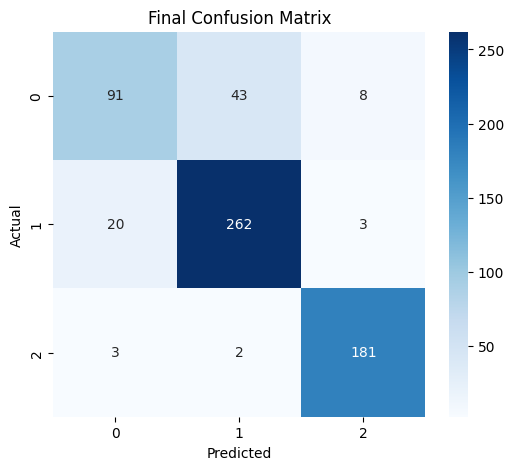

              precision    recall  f1-score   support

           0       0.80      0.64      0.71       142
           1       0.85      0.92      0.89       285
           2       0.94      0.97      0.96       186

    accuracy                           0.87       613
   macro avg       0.86      0.84      0.85       613
weighted avg       0.87      0.87      0.87       613



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred))

In [16]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=1)
print("Final Validation Accuracy:", val_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.8873 - loss: 0.3418
Final Validation Accuracy: 0.8711256384849548


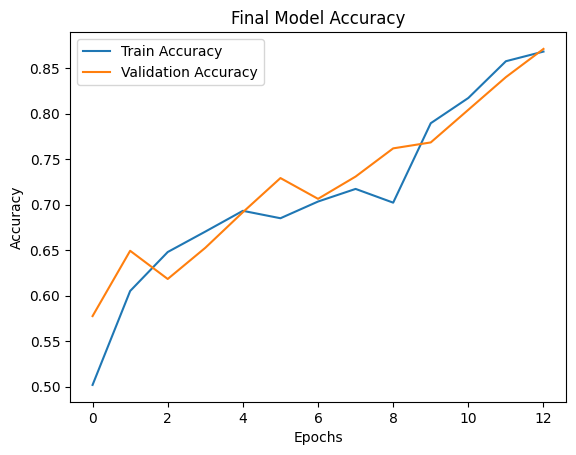

In [17]:
import matplotlib.pyplot as plt

# Combine histories if you used fine-tuning
plt.plot(history.history['accuracy'] + history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'] + history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Final Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
model.save("brain_tumor_resnet50_final.h5")